Multi-fidelity Modeling and Experimental Design (Active Learning)

In [1]:
# General imports

import numpy as np
np.random.seed(20)
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os
sys.path.append('../utilities')
import simulation_utils as sim
import plotting_utils as plotting
import drawing_utils as draw_mfsm
import gp_regression_surrogate_model as mfsm
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array
import random
import math
from sklearn.metrics import mean_squared_error

In [ ]:
version = 'vgplf1.1'
nsampes = 305
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')

# Set parameter name/x_labels -> needs to be consistent with data input file
#x_labels=['Radius[cm]','Thickness[cm]','Theta[deg]','Length[cm]']
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,4,0,0,0]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.

# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)

# Get HF and LF data samples from file
data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],'Ge77-Rate[nucleus/(kg yr)]']]

data=pd.read_csv(f'in/{file_in}')
data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4] ,y_label_sim]]


#LF_noise=np.mean(data.loc[data['Mode']==0.][y_err_label_cnp].to_numpy())
#HF_noise=np.mean(data.loc[data['Mode']==1.][y_err_label_cnp].to_numpy())

In [ ]:

x_train_h, y_train_h = ([],[])
row_h=data.index[data['Mode'] == 1].tolist()

x_train_hf_sim = data.loc[data['Mode']==0.][x_labels].to_numpy()[0:nsampes].tolist()
y_train_hf_sim = data.loc[data['Mode']==0.][y_label_sim].to_numpy()[0:nsampes].tolist()

x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)



In [4]:
mf_model = mfsm.linear_multi_fidelity_model(x_train_hf_sim, y_train_hf_sim)

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/GPy/kern/src/stationary.py:168: RuntimeWarning:overflow encountered in divide
 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/GPy/kern/src/rbf.py:76: RuntimeWarning:invalid value encountered in multiply


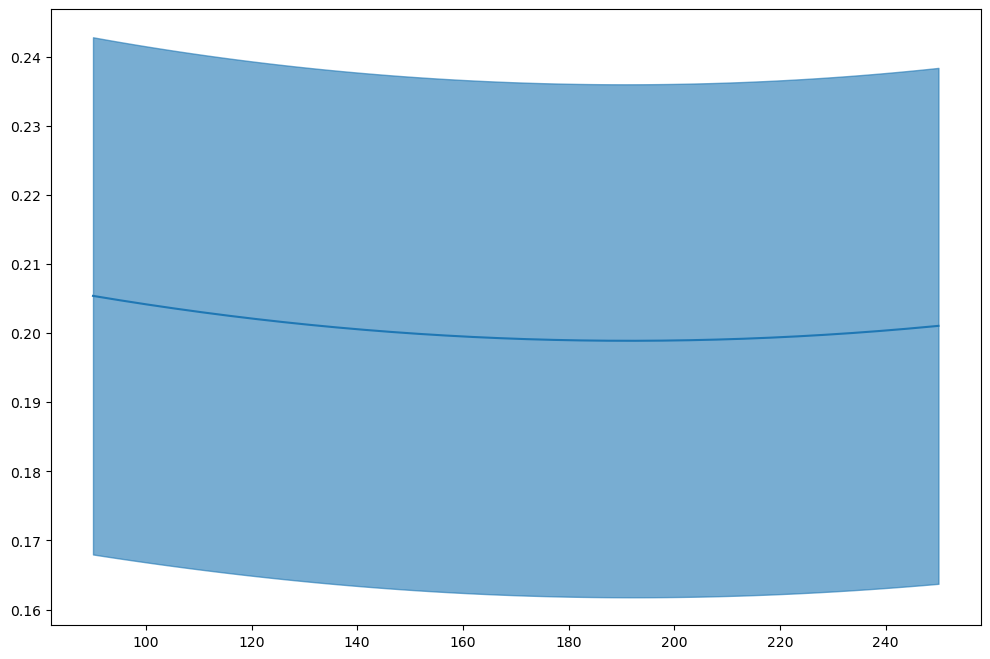

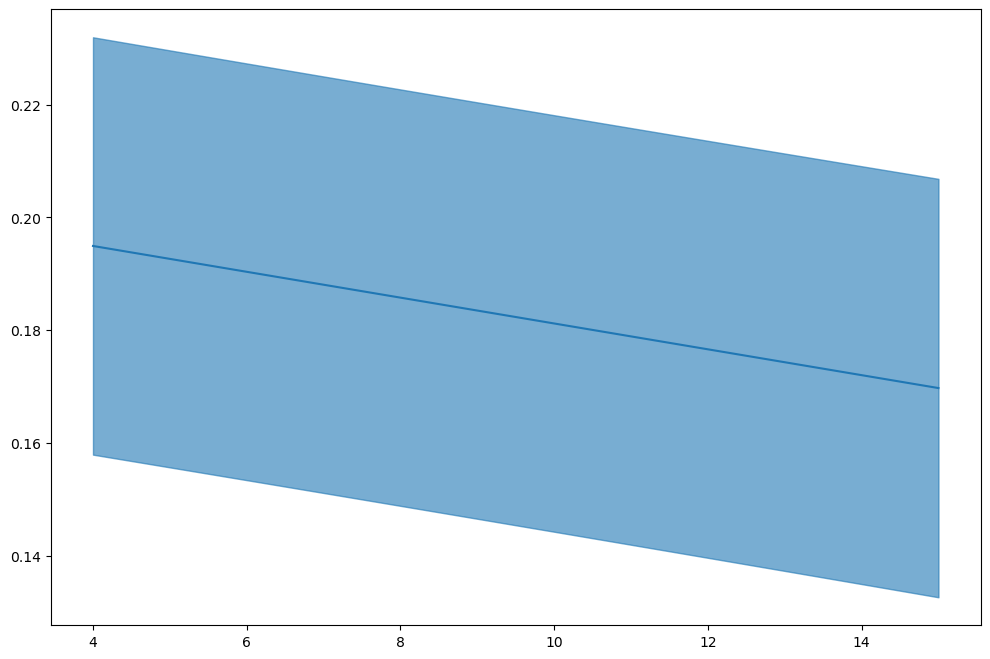

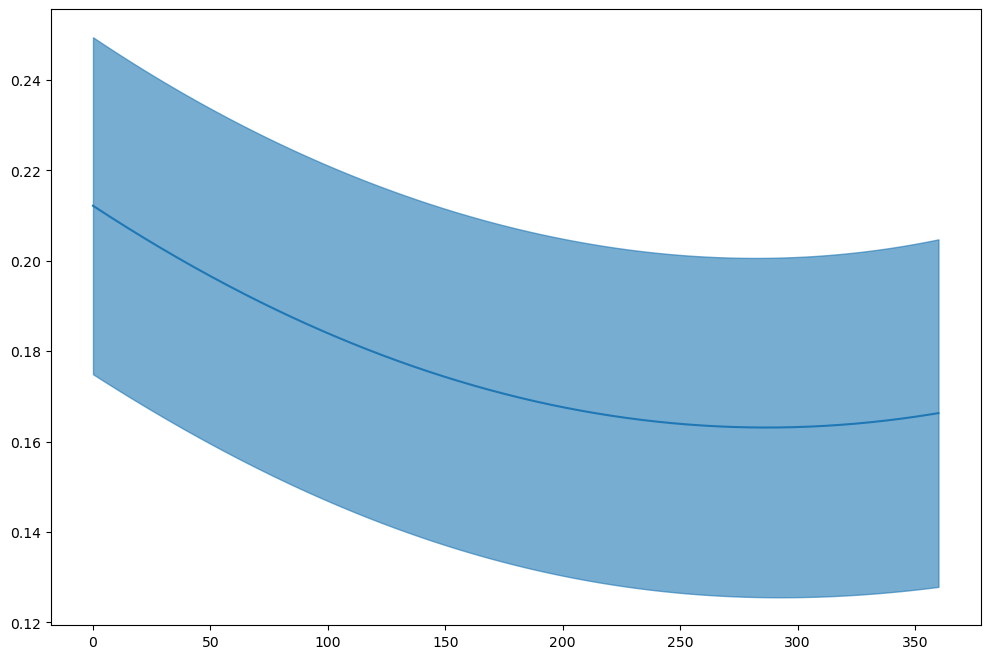

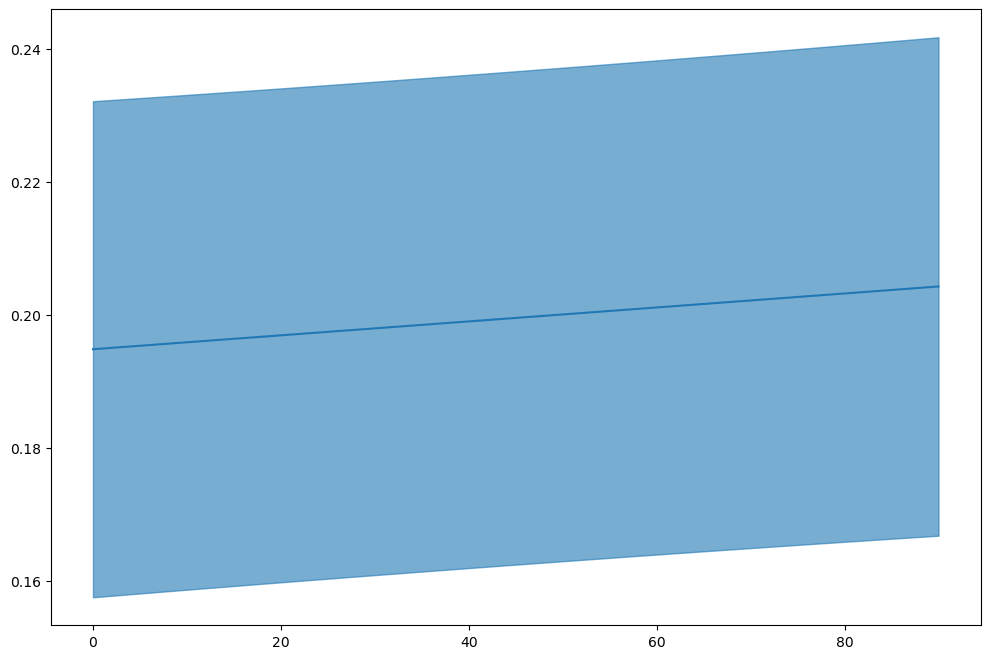

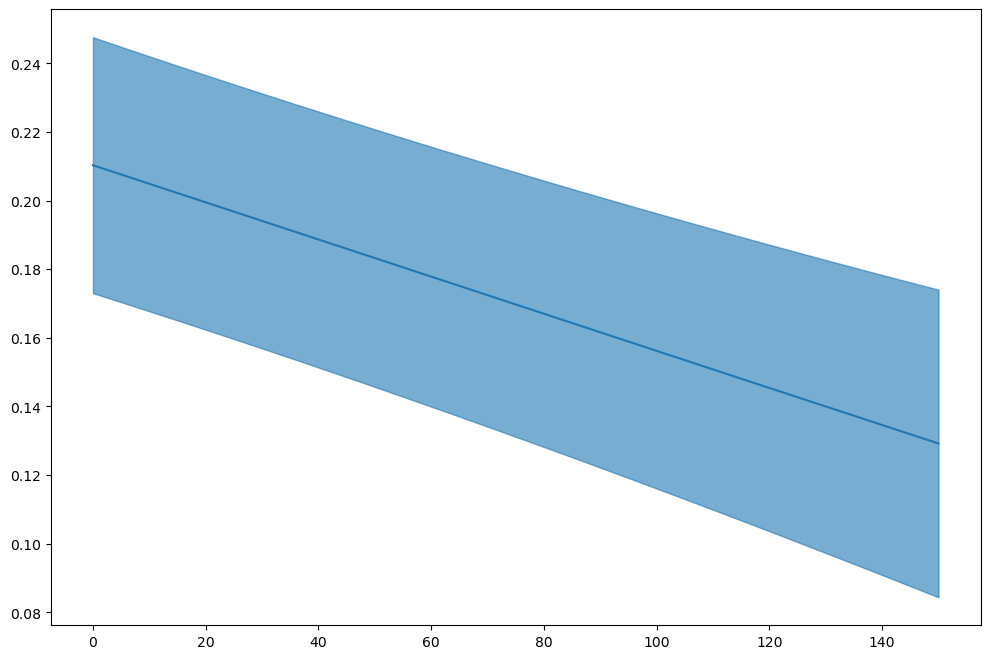

In [5]:
SPLIT = 500
for i in range(len(x_labels)):  
        x_labels2 = ["r","b","N","$\theta$","L"]
        x_fix_tmp = [str(round(x,1)) for x in x_fixed]
        x_fix_tmp[i] = x_labels2[i]
        label_tmp = r"Projection on x(r,b,N,$\theta$,L)=["
        for x in x_fix_tmp[:-1]:
            label_tmp += fr"{x},"
        label_tmp += f"{x_fix_tmp[-1]}]"
        ## Compute mean and variance predictions
        x_plot=[x_fixed[:] for l in range(0,SPLIT)]
        x_tmp = np.linspace(xlow[i], xhigh[i], SPLIT)
        for k in range(0,SPLIT):
            x_plot[k][i]=x_tmp[k]
        x_plot = (np.atleast_2d(x_plot))

        hf_mean_mf_model, hf_var_mf_model = mf_model.predict(x_plot)
        hf_std_mf_model = np.sqrt(hf_var_mf_model)
        plt.figure(figsize=(12, 8))
        plt.fill_between(x_plot[:, i],
                hf_mean_mf_model[:, 0] + hf_std_mf_model[:, 0],
                hf_mean_mf_model[:, 0] - hf_std_mf_model[:, 0], color="C0", alpha=0.6)
        plt.plot(x_plot[:,i], hf_mean_mf_model, "C0", label="Model")
    



In [6]:
%%capture
leg_label = []
ncol=1
nrow=int(np.ceil(len(x_labels)/ncol))
fig1,ax1  = plt.subplots(nrow,ncol, figsize=(5, 12),layout="constrained")
fig2,ax2  = plt.subplots(nrow,ncol, figsize=(5, 12),layout="constrained")

In [7]:
add_new_sample=True
sample=0
total_samples=20

In [8]:
def model_validation(mf_model, file_in, x_labels, y_label, version, nfidelities=2):
        data=pd.read_csv(file_in)
        #data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label]]

        x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
        y_train_hf_sim = data.loc[data['Mode']==1.][y_label].to_numpy().tolist()
        x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)

        counter_1sigma = 0
        counter_2sigma = 0
        counter_3sigma = 0

        mfsm_model_mean = np.empty(shape=[0, 0])
        mfsm_model_std = np.empty(shape=[0, 0])
        hf_data=[]
        x=[]
        MSE=0
        NMSE=0
        MAE=0
        MSSE=0
        for i in range(len(x_train_hf_sim)):

                SPLIT = 1
                x_plot = (np.atleast_2d(x_train_hf_sim[i]))
                X_plot = convert_x_list_to_array([x_plot , x_plot, x_plot])
                hhf_mean_mf_model, hhf_var_mf_model = mf_model.predict(X_plot[SPLIT*(nfidelities-1):SPLIT*(nfidelities)])
                hhf_std_mf_model = np.sqrt(hhf_var_mf_model)

                hf_data.append(y_train_hf_sim[i][0])
                x.append(i)
                mfsm_model_mean=np.append(mfsm_model_mean,hhf_mean_mf_model[0,0])
                mfsm_model_std=np.append(mfsm_model_std,hhf_std_mf_model[0,0])

                if (y_train_hf_sim[i][0] < hhf_mean_mf_model[0][0]+hhf_std_mf_model[0][0]) and (y_train_hf_sim[i][0] > hhf_mean_mf_model[0][0]-hhf_std_mf_model[0][0]):
                        counter_1sigma += 1
                if (y_train_hf_sim[i][0] < hhf_mean_mf_model[0][0]+2*hhf_std_mf_model[0][0]) and (y_train_hf_sim[i][0] > hhf_mean_mf_model[0][0]-2*hhf_std_mf_model[0][0]):
                        counter_2sigma += 1
                if (y_train_hf_sim[i][0] < hhf_mean_mf_model[0][0]+3*hhf_std_mf_model[0][0]) and (y_train_hf_sim[i][0] > hhf_mean_mf_model[0][0]-3*hhf_std_mf_model[0][0]):
                        counter_3sigma += 1
                
                MAE +=np.abs(y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])
                MSE +=pow(y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0],2)
                NMSE +=np.abs((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0])
                MSSE +=pow((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0],2)


        if (counter_2sigma/len(hf_data)*100.==100. and counter_3sigma/len(hf_data)*100.==100. and counter_1sigma/len(hf_data)*100.<68.):
                counter_1sigma=counter_2sigma=counter_3sigma=0.
        percentage_1sigma=counter_1sigma/len(hf_data)*100.
        percentage_2sigma=counter_2sigma/len(hf_data)*100.
        percentage_3sigma=counter_3sigma/len(hf_data)*100.
        print("1 sigma: ", percentage_1sigma," %" )
        print("2 sigma: ", percentage_2sigma," %" )
        print("3 sigma: ", percentage_3sigma," %" )

        
        fig = plt.subplots(figsize=(12, 2.5))
        #plt.bar(x=np.arange(len(mfsm_model_mean)), height=mfsm_model_mean, color="lightgray", label='RESuM')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-3*mfsm_model_std, y2=mfsm_model_mean+3*mfsm_model_std, color="coral",alpha=0.2, label=r'$\pm 3\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-2*mfsm_model_std, y2=mfsm_model_mean+2*mfsm_model_std, color="yellow",alpha=0.2, label=r'$\pm 2\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-mfsm_model_std, y2=mfsm_model_mean+mfsm_model_std, color="green",alpha=0.2, label=r'RESuM $\pm 1\sigma$')
        plt.xlabel('HF Simulation Trial Number')
        plt.ylim(0.,0.55)
        plt.ylabel(r'$y_{raw}$')
        plt.plot(x[:],hf_data[:],'.',color="black", label="HF Validation Data")
        handles, labels = plt.gca().get_legend_handles_labels()
        order = [3,2,1,0]
        plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
        plt.savefig(f'out/{version}/model-validation_{version}.pdf')
        
        MAE=MAE/len(x_train_hf_sim)
        mse = mean_squared_error(hf_data,mfsm_model_mean, squared=True)
        NMSE=NMSE/len(x_train_hf_sim)
        return [percentage_1sigma,percentage_2sigma,percentage_3sigma,MAE,NMSE,mse,MSSE]

1 sigma:  88.0  %
2 sigma:  100.0  %
3 sigma:  100.0  %


[88.0,
 100.0,
 100.0,
 0.020133768254335528,
 0.5409968425100973,
 0.0005773121007751982,
 41.71111942278868]

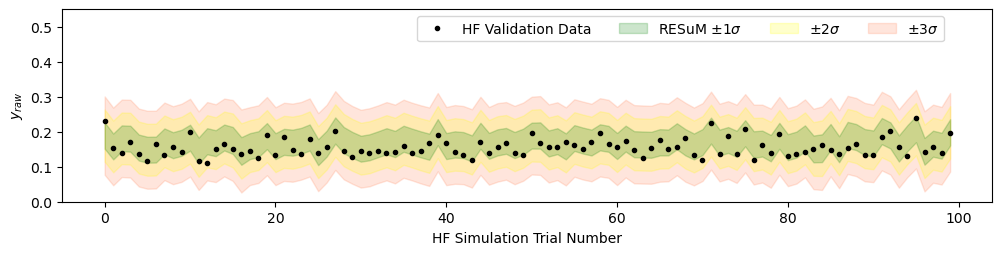

In [9]:
model_validation(mf_model,"in/hf_validation_data_v1.2.csv",x_labels, y_label_sim, version,1)
